requirements.txt 

numpy
pandas
matplotlib
seaborn
scikit-learn
statsmodels
ipykernel

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

import itertools

In [2]:
df = pd.read_csv("hdb-resale-July-2020.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2456 entries, 0 to 2455
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                2456 non-null   str    
 1   town                 2456 non-null   str    
 2   flat_type            2456 non-null   str    
 3   block                2456 non-null   str    
 4   street_name          2456 non-null   str    
 5   storey_range         2456 non-null   str    
 6   floor_area_sqm       2456 non-null   float64
 7   flat_model           2456 non-null   str    
 8   lease_commence_date  2456 non-null   int64  
 9   remaining_lease      2456 non-null   str    
 10  resale_price         2456 non-null   float64
dtypes: float64(2), int64(1), str(8)
memory usage: 211.2 KB


In [4]:
for col in df.columns:
    print(df[col].value_counts())

# The month column has only 1 type of value

month
2020-07    2456
Name: count, dtype: int64
town
PUNGGOL            205
SENGKANG           195
YISHUN             172
TAMPINES           170
WOODLANDS          165
BEDOK              151
JURONG WEST        148
BUKIT PANJANG      133
HOUGANG            130
CHOA CHU KANG      114
ANG MO KIO          96
PASIR RIS           96
BUKIT BATOK         81
TOA PAYOH           76
CLEMENTI            74
BUKIT MERAH         71
QUEENSTOWN          63
SEMBAWANG           62
GEYLANG             61
JURONG EAST         53
KALLANG/WHAMPOA     41
SERANGOON           34
BISHAN              28
CENTRAL AREA        19
MARINE PARADE       12
BUKIT TIMAH          6
Name: count, dtype: int64
flat_type
4 ROOM              985
3 ROOM              614
5 ROOM              599
EXECUTIVE           193
2 ROOM               62
1 ROOM                2
MULTI-GENERATION      1
Name: count, dtype: int64
block
121     10
114     10
2       10
308A     9
5        9
        ..
333A     1
873      1
405      1
724      1
633

In [5]:
df = (df[~((df['flat_type'] == 'MULTI-GENERATION') | (df['flat_model'] == 'Type S2'))] # Only 1 data point with multi-generation and 1 data point with type S2
    .reset_index(drop=True)
)

In [6]:
df = df.drop(columns=['month']) # Drop month column since every data point has month=July 2020

In [7]:
def parse_lease(s):
    years = 0
    months = 0
    if 'years' in s:
        years = int(s.split('years')[0].strip())
    if 'months' in s:
        months = int(s.split('years')[1].replace('months', '').strip())
    return years + months / 12

df['remaining_lease_years'] = df['remaining_lease'].apply(parse_lease)

In [8]:
df['storey_range'].value_counts()
# always 2 storeys apart

storey_range
04 TO 06    582
07 TO 09    487
01 TO 03    456
10 TO 12    454
13 TO 15    255
16 TO 18    114
19 TO 21     31
22 TO 24     28
25 TO 27     21
28 TO 30     11
37 TO 39      4
40 TO 42      4
34 TO 36      3
31 TO 33      3
49 TO 51      1
Name: count, dtype: int64

In [9]:
df['average_storey'] = df['storey_range'].apply(
    lambda x: (int(x.split(' TO ')[0]) + int(x.split(' TO ')[1])) / 2
) # Creates an ordering

In [10]:
# URA Official Planning Regions Mapping
region_mapping = {
    # Central Region
    'BISHAN': 'Central', 'BUKIT MERAH': 'Central', 'BUKIT TIMAH': 'Central', 
    'CENTRAL AREA': 'Central', 'GEYLANG': 'Central', 'KALLANG/WHAMPOA': 'Central', 
    'MARINE PARADE': 'Central', 'QUEENSTOWN': 'Central', 'TOA PAYOH': 'Central',
    
    # North Region
    'SEMBAWANG': 'North', 'WOODLANDS': 'North', 'YISHUN': 'North',
    
    # North-East Region
    'ANG MO KIO': 'North-East', 'HOUGANG': 'North-East', 'PUNGGOL': 'North-East', 
    'SENGKANG': 'North-East', 'SERANGOON': 'North-East',
    
    # East Region
    'BEDOK': 'East', 'PASIR RIS': 'East', 'TAMPINES': 'East',
    
    # West Region
    'BUKIT BATOK': 'West', 'BUKIT PANJANG': 'West', 'CHOA CHU KANG': 'West', 
    'CLEMENTI': 'West', 'JURONG EAST': 'West', 'JURONG WEST': 'West'
}

# Apply the mapping
df['region'] = df['town'].map(region_mapping)

In [11]:
market_segment_mapping = {
    # Core Central Region (CCR) - The absolute core
    'CENTRAL AREA': 'CCR', 
    'BUKIT TIMAH': 'CCR', 
    
    # Rest of Central Region (RCR) - The city fringe
    'BISHAN': 'RCR', 
    'BUKIT MERAH': 'RCR', 
    'GEYLANG': 'RCR', 
    'KALLANG/WHAMPOA': 'RCR', 
    'MARINE PARADE': 'RCR', 
    'QUEENSTOWN': 'RCR', 
    'TOA PAYOH': 'RCR',
    
    # Outside Central Region (OCR) - The suburban mass market
    'ANG MO KIO': 'OCR', 
    'BEDOK': 'OCR', 
    'BUKIT BATOK': 'OCR', 
    'BUKIT PANJANG': 'OCR', 
    'CHOA CHU KANG': 'OCR', 
    'CLEMENTI': 'OCR', 
    'HOUGANG': 'OCR', 
    'JURONG EAST': 'OCR', 
    'JURONG WEST': 'OCR', 
    'PASIR RIS': 'OCR', 
    'PUNGGOL': 'OCR', 
    'SEMBAWANG': 'OCR', 
    'SENGKANG': 'OCR', 
    'SERANGOON': 'OCR', 
    'TAMPINES': 'OCR', 
    'WOODLANDS': 'OCR', 
    'YISHUN': 'OCR'
}

# Apply the mapping to create your new feature
#df['market_segment'] = df['town'].map(market_segment_mapping) 
# decided to use region instead

In [12]:
df = df.drop(columns = ['town', 'block', 'street_name', 'storey_range', 'remaining_lease']) # dropping unneccesary columns

In [13]:
df

,flat_type,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease_years,average_storey,region
0,2 ROOM,44.0,Improved,1978,198000.0,56.583333,5.0,North-East
1,2 ROOM,44.0,Improved,1978,207000.0,56.500000,5.0,North-East
2,2 ROOM,44.0,Improved,1980,198000.0,59.000000,2.0,North-East
3,2 ROOM,44.0,Improved,1980,208000.0,58.916667,2.0,North-East
4,3 ROOM,82.0,New Generation,1976,290000.0,54.916667,11.0,North-East
...,...,...,...,...,...,...,...,...
2449,EXECUTIVE,142.0,Apartment,1988,575000.0,67.166667,2.0,North
2450,EXECUTIVE,146.0,Maisonette,1987,575000.0,66.250000,11.0,North
2451,EXECUTIVE,146.0,Maisonette,1987,568888.0,65.833333,5.0,North
2452,EXECUTIVE,142.0,Apartment,1987,540000.0,66.166667,11.0,North


# **Part I. EDA**

In [14]:
sns.set_style("white")
plt.style.use("ggplot")

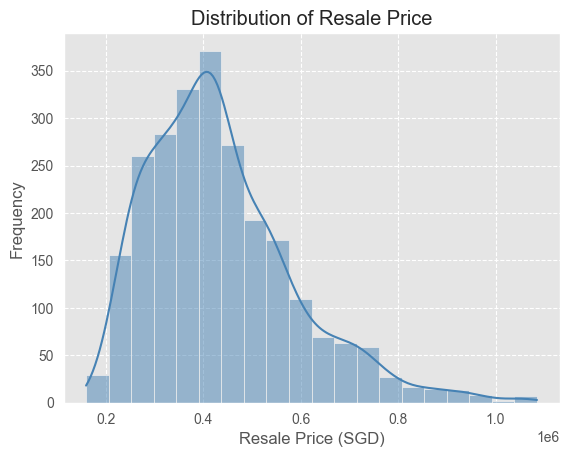

In [15]:
sns.histplot(df['resale_price'], bins=20, kde=True, color='steelblue')
plt.xlabel('Resale Price (SGD)')
plt.ylabel('Frequency')
plt.title('Distribution of Resale Price')

plt.grid(True, zorder=0, linestyle='--')
plt.show()

Comments: Histogram is right skewed, and not symmetric => Normality assumption possible violated

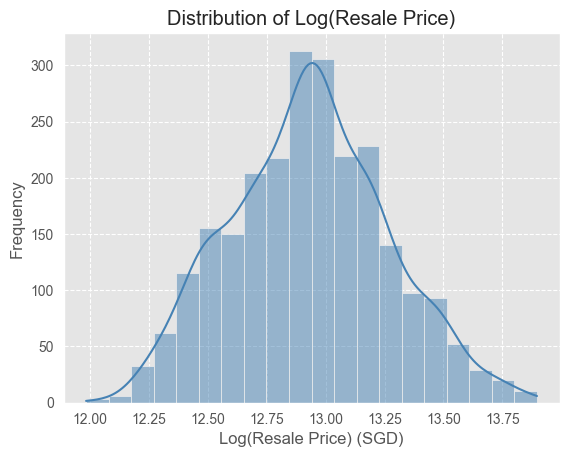

In [16]:
sns.histplot(np.log(df['resale_price']), bins=20, kde=True, color='steelblue')
plt.xlabel('Log(Resale Price) (SGD)')
plt.ylabel('Frequency')
plt.title('Distribution of Log(Resale Price)')

plt.grid(True, zorder=0, linestyle='--')
plt.show()

Comments: After log transforming the response variable `resale_price`, the new histograms looks more symmetric => Satisfies the normality assumption better

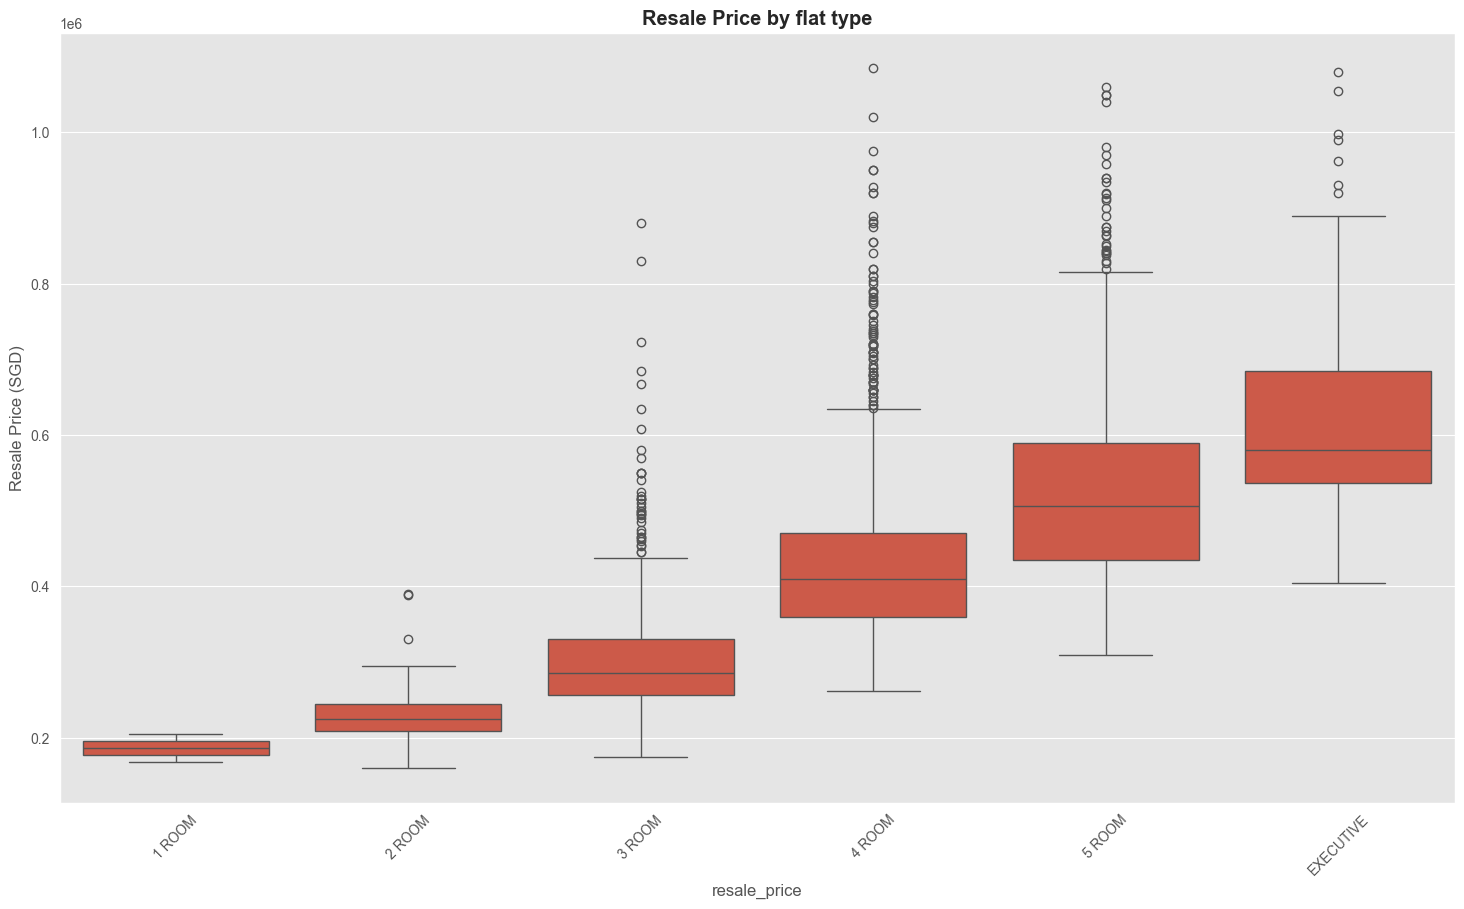

In [17]:
fig, axes = plt.subplots(1, 1, figsize=(18, 10))

order = ['1 ROOM', '2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE']

sns.boxplot(data=df, x="flat_type", y="resale_price", ax=axes, order=order)
axes.set_title(f'Resale Price by flat type', fontweight='bold')
axes.set_xlabel(col)
axes.set_ylabel('Resale Price (SGD)')
axes.tick_params(axis='x', rotation=45)

Comments: Expected trend, the bigger the house, then the more expensive the resale price (SGD)

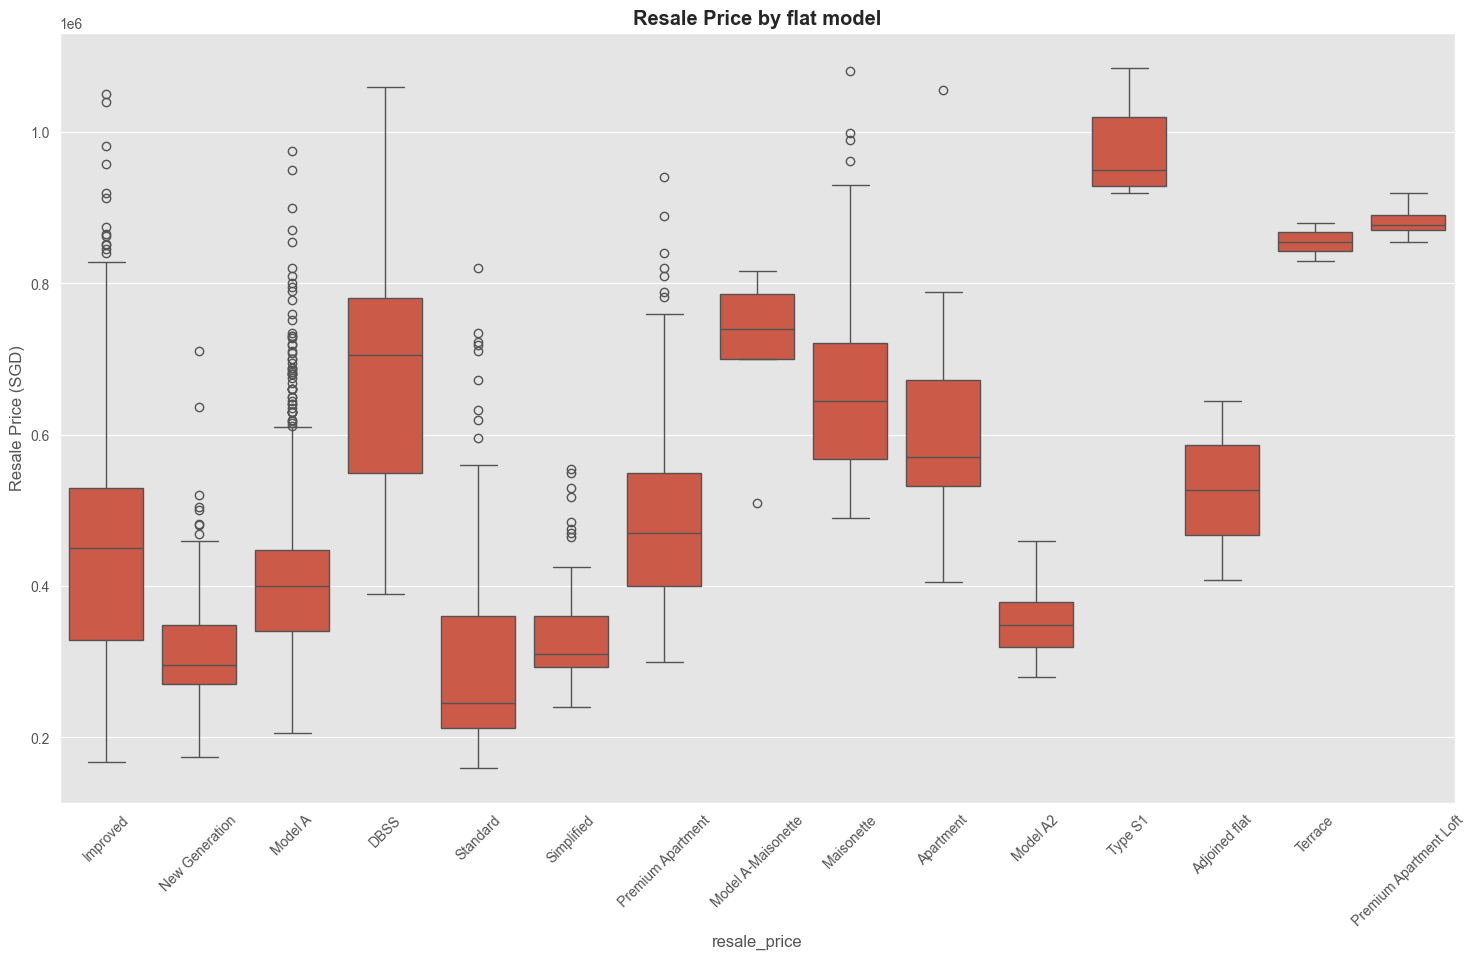

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(18, 10))

sns.boxplot(data=df, x="flat_model", y="resale_price", ax=axes)
axes.set_title(f'Resale Price by flat model', fontweight='bold')
axes.set_xlabel(col)
axes.set_ylabel('Resale Price (SGD)')
axes.tick_params(axis='x', rotation=45)

Here's a brief explanation of each HDB flat model:

**Standard Models**
- **Improved** — older basic HDB design, common in early estates
- **Standard** — similar to Improved, basic layout built in the 1970s–80s
- **Simplified** — a more compact, cost-efficient version of the standard design

**Upgraded/Newer Models**
- **New Generation** — introduced in the 1970s, improved layout with better space utilisation
- **Model A** — popular 1980s–90s design with a more modern layout, includes utility room
- **Model A2** — variant of Model A with slight layout differences
- **DBSS** — Design, Build and Sell Scheme; built by private developers with condo-like finishes, no longer in production

**Premium Models**
- **Premium Apartment** — higher-end finish, typically in mature estates
- **Premium Apartment Loft** — premium apartment with a double-storey loft layout
- **Apartment** — standard apartment layout, typically in taller blocks

**Maisonette Models**
- **Maisonette** — two-storey unit within an HDB block, no longer built
- **Model A-Maisonette** — Model A layout in a two-storey maisonette format

**Specialty/Rare Models**
- **Type S1 / Type S2** — larger special layouts, rare and mostly in specific estates
- **Adjoined Flat** — two units joined together to form one larger flat
- **Terrace** — HDB terrace house, very rare, found in a few estates like Toa Payoh
- **Multi Generation** — paired main flat and studio unit for extended families

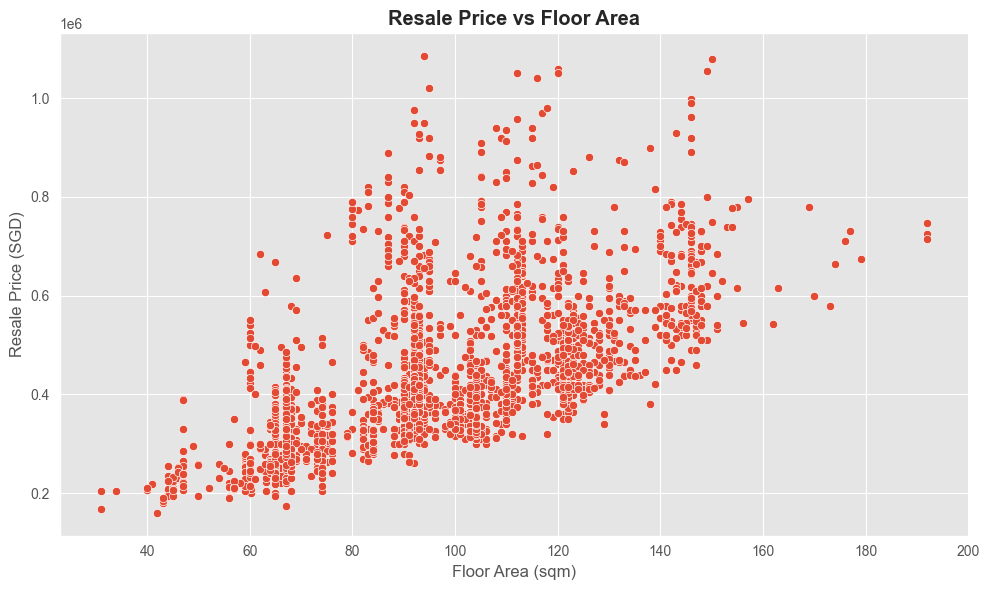

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='floor_area_sqm', y='resale_price')
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price (SGD)')
plt.title('Resale Price vs Floor Area', fontweight='bold')
plt.tight_layout()
plt.show()

Comments: Linear association between floor area(sqm) and resale_price. However, variance of resale_price might be unstable as floor_area-sqm increases.

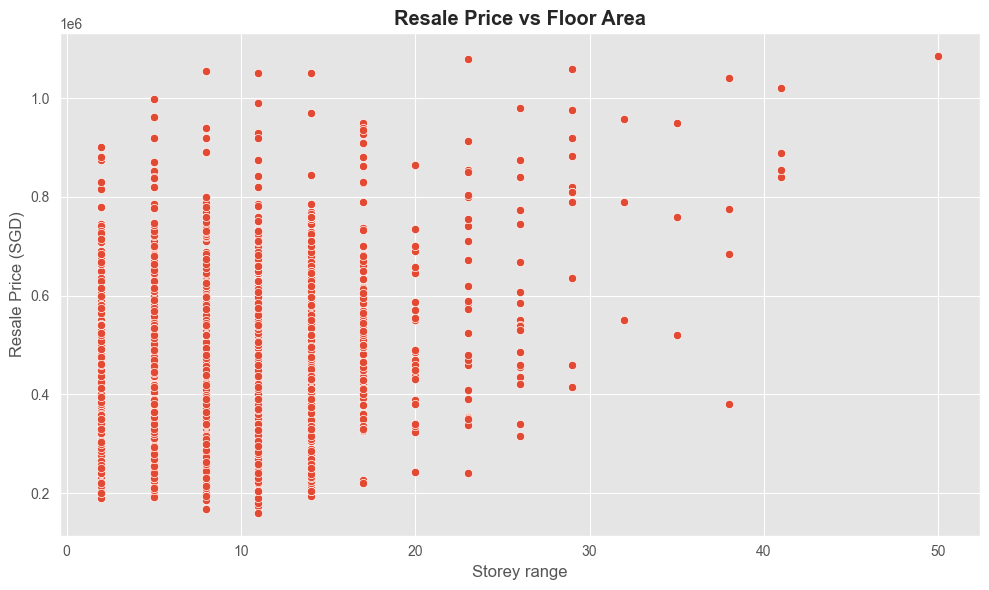

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='average_storey', y='resale_price')
plt.xlabel('Storey range')
plt.ylabel('Resale Price (SGD)')
plt.title('Resale Price vs Floor Area', fontweight='bold')
plt.tight_layout()
plt.show()

Comments: Relationship between storey range is not that obvious. Most of the data points are flats on storeys less than 20

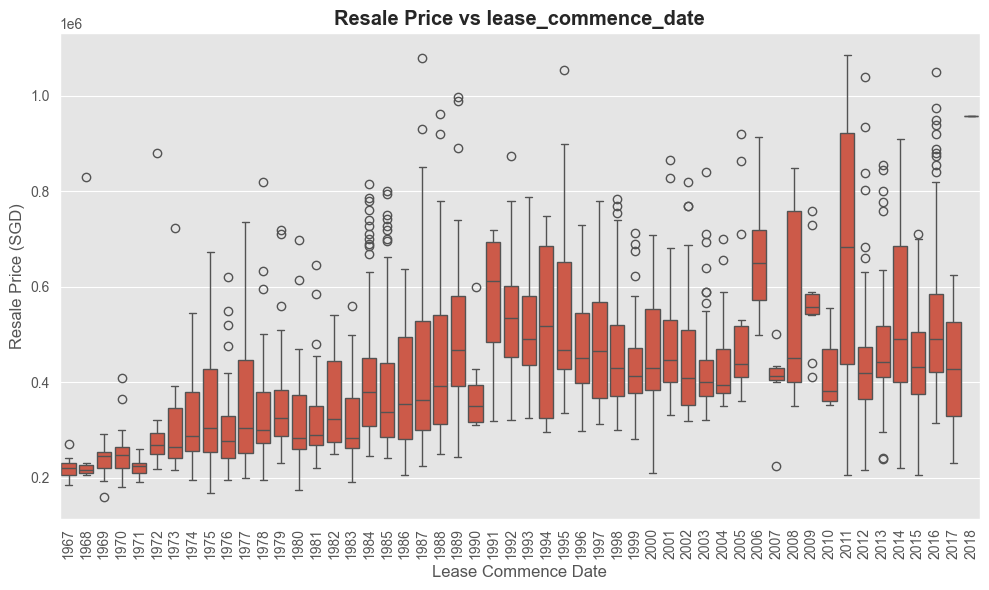

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='lease_commence_date', y='resale_price')
plt.xlabel('Lease Commence Date')
plt.ylabel('Resale Price (SGD)')
plt.title('Resale Price vs lease_commence_date', fontweight='bold')
plt.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Comments: Newer leases are generally more expensive. There is also a huge spike in resale price in 2018.

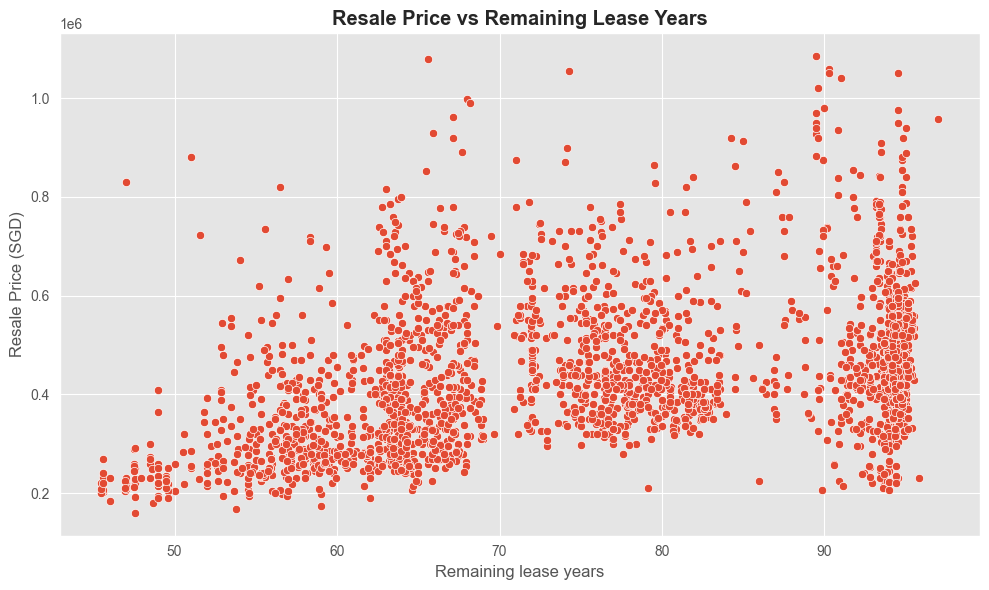

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='remaining_lease_years', y='resale_price')
plt.xlabel('Remaining lease years')
plt.ylabel('Resale Price (SGD)')
plt.title('Resale Price vs Remaining Lease Years', fontweight='bold')
plt.tight_layout()
plt.show()

Comments: Some association between remaining lease and resale price. Uncertain of the linearity. Variance is also unstable as remaining lease increases.

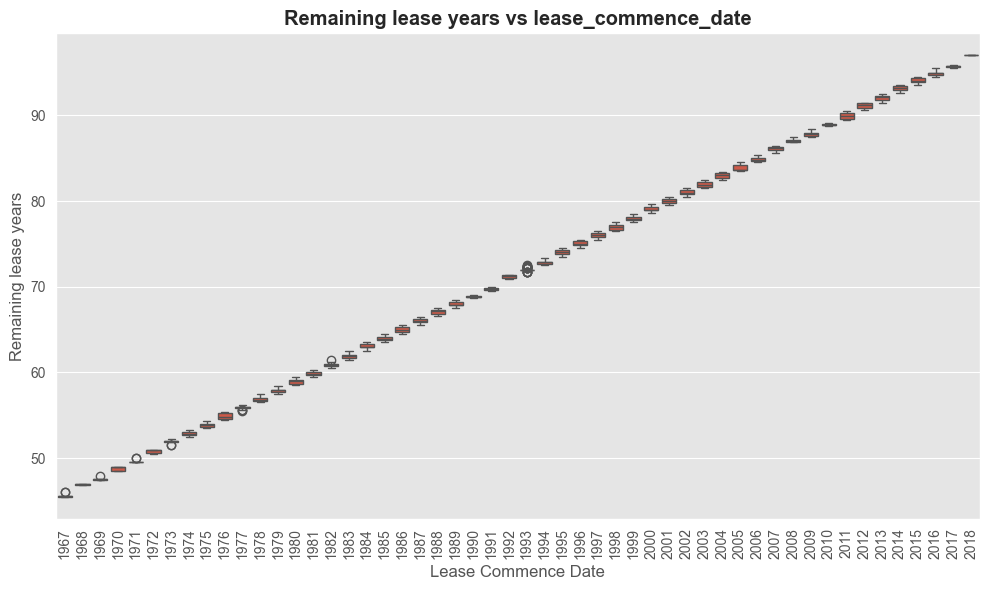

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='lease_commence_date', y='remaining_lease_years')
plt.xlabel('Lease Commence Date')
plt.ylabel('Remaining lease years')
plt.title('Remaining lease years vs lease_commence_date', fontweight='bold')
plt.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Comments: Lease_commence_date has a positive association with remaining lease years. Might indicate multicollinearity

In [24]:
df

,flat_type,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease_years,average_storey,region
0,2 ROOM,44.0,Improved,1978,198000.0,56.583333,5.0,North-East
1,2 ROOM,44.0,Improved,1978,207000.0,56.500000,5.0,North-East
2,2 ROOM,44.0,Improved,1980,198000.0,59.000000,2.0,North-East
3,2 ROOM,44.0,Improved,1980,208000.0,58.916667,2.0,North-East
4,3 ROOM,82.0,New Generation,1976,290000.0,54.916667,11.0,North-East
...,...,...,...,...,...,...,...,...
2449,EXECUTIVE,142.0,Apartment,1988,575000.0,67.166667,2.0,North
2450,EXECUTIVE,146.0,Maisonette,1987,575000.0,66.250000,11.0,North
2451,EXECUTIVE,146.0,Maisonette,1987,568888.0,65.833333,5.0,North
2452,EXECUTIVE,142.0,Apartment,1987,540000.0,66.166667,11.0,North


# **Part II. Model Training**

In [25]:
categorical_features = ["flat_type", "flat_model", "region"]
numerical_features = ["floor_area_sqm", "lease_commence_date", "remaining_lease_years", "average_storey"]

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
], remainder='passthrough')

X_processed = preprocessor.fit_transform(df.drop(columns=['resale_price']))
y = np.log(df['resale_price'])

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

## Model 1: Baseline model with all feature variables

In [27]:

# Get feature names
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(cat_feature_names) + numerical_features

X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)
X_processed_df = sm.add_constant(X_processed_df)

model_one = sm.OLS(y, X_processed_df).fit()
print(model_one.summary())

                            OLS Regression Results                            
Dep. Variable:           resale_price   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     552.5
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:45:00   Log-Likelihood:                 1615.9
No. Observations:                2454   AIC:                            -3176.
Df Residuals:                    2426   BIC:                            -3013.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [28]:
formula = 'np.log(resale_price) ~ ' + ' + '.join(categorical_features + numerical_features)

model_one_formula = smf.ols(formula, data=df).fit()

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print(sm.stats.anova_lm(model_one_formula, typ=1))

                           df      sum_sq    mean_sq            F         PR(>F)
flat_type                 5.0  148.508804  29.701761  1871.659958   0.000000e+00
flat_model               14.0   38.144487   2.724606   171.691381   0.000000e+00
region                    4.0   26.857717   6.714429   423.110546  7.942391e-277
floor_area_sqm            1.0    0.000025   0.000025     0.001594   9.681515e-01
lease_commence_date       1.0   17.541336  17.541336  1105.369330  4.772901e-200
remaining_lease_years     1.0    0.021004   0.021004     1.323550   2.500693e-01
average_storey            1.0    5.646938   5.646938   355.842480   3.564084e-74
Residual               2426.0   38.498698   0.015869          NaN            NaN


In [29]:
influence = model_one.get_influence()
std_resid = influence.resid_studentized_internal  # standardized (internal)

In [30]:
influence = model_one.get_influence()
leverage  = influence.hat_matrix_diag

print(f"Max leverage:         {leverage.max():.4f}")
print(f"hii == 1 count:       {(leverage > 0.9999).sum()}")
print(f"hii > 2*p/n:      {(leverage > 2*(X_processed_df.shape[1])/len(y)).sum()}")

print("-------------------------------------")
# Find leverage points
leverage_idx = np.where(leverage > 2*(X_processed_df.shape[1])/len(y))[0]
print(df.iloc[leverage_idx][categorical_features].value_counts())

Max leverage:         0.5059
hii == 1 count:       0
hii > 2*p/n:      87
-------------------------------------
flat_type  flat_model              region    
EXECUTIVE  Premium Apartment       West          10
4 ROOM     Model A2                West           9
EXECUTIVE  Apartment               North          9
4 ROOM     Model A2                North          7
2 ROOM     Standard                Central        6
EXECUTIVE  Premium Apartment       North-East     6
4 ROOM     Type S1                 Central        5
EXECUTIVE  Premium Apartment       North          5
4 ROOM     Model A2                North-East     4
           Premium Apartment Loft  Central        4
2 ROOM     Improved                North-East     2
                                   East           2
1 ROOM     Improved                Central        2
5 ROOM     Model A-Maisonette      West           2
3 ROOM     Terrace                 Central        2
5 ROOM     Model A-Maisonette      East           1
          

/var/folders/qv/xzq6rspd7nv2j8g1qndx4g800000gn/T/ipykernel_47603/801361374.py:12: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(x_line, slope_iqr * x_line + intercept_iqr, 'r-', lw=2, zorder=3, linestyle='--')


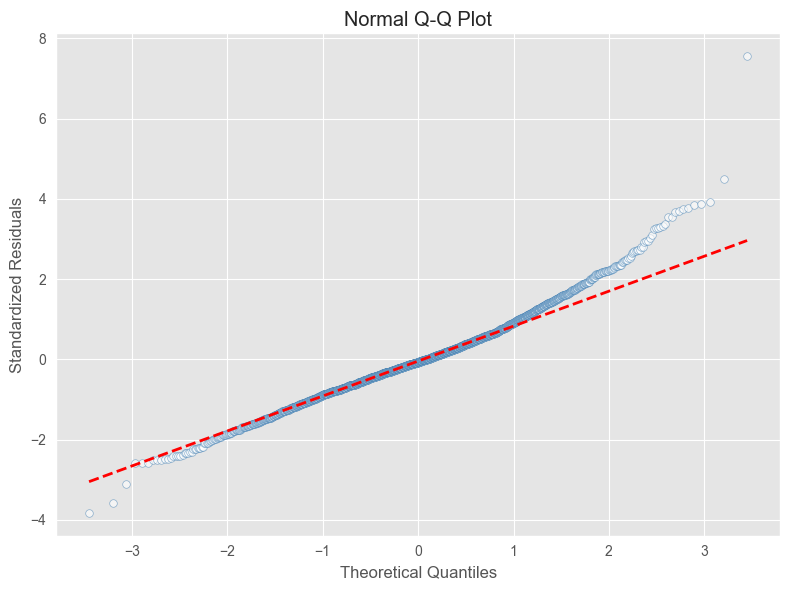

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

(osm, osr), (slope, intercept, _) = stats.probplot(std_resid, dist="norm")
ax.scatter(osm, osr, alpha=0.6, edgecolors='steelblue', facecolors='white', s=30)

q25, q75 = np.percentile(std_resid[~np.isnan(std_resid)], [25, 75])
norm_q25, norm_q75 = stats.norm.ppf([0.25, 0.75])
slope_iqr = (q75 - q25) / (norm_q75 - norm_q25)
intercept_iqr = q25 - slope_iqr * norm_q25

x_line = np.linspace(min(osm), max(osm), 100)
ax.plot(x_line, slope_iqr * x_line + intercept_iqr, 'r-', lw=2, zorder=3, linestyle='--')

ax.set_title("Normal Q-Q Plot")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Standardized Residuals")

plt.tight_layout()
plt.show()

Comments: QQPlot has a slightly light tailed distribution. There are also some outliers on the left and right.

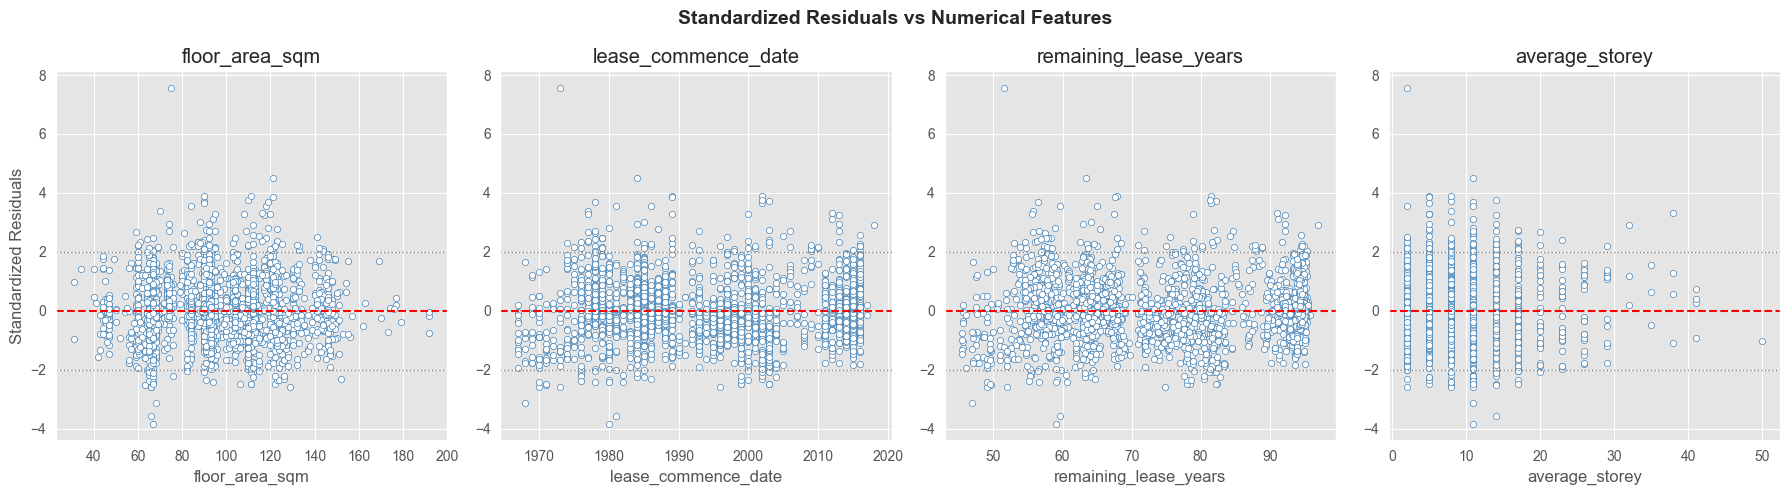

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Standardized Residuals vs Numerical Features", fontsize=14, fontweight='bold')

for i, feature in enumerate(numerical_features):
    ax = axes[i]
    ax.scatter(df[feature], std_resid, edgecolors='steelblue', facecolors='white', s=20)

    ax.axhline(0, color='red', linestyle='--', lw=1.5)
    ax.axhline(2, color='gray', linestyle=':', lw=1)
    ax.axhline(-2, color='gray', linestyle=':', lw=1)
    ax.set_xlabel(feature)
    ax.set_ylabel("Standardized Residuals" if i == 0 else "")
    ax.set_title(feature)

plt.tight_layout()
plt.show()

Comments: 
- floor_area_sqm: slight funnel shape widening to the right, suggesting heteroscedasticity: larger flats have more variance in residuals.
- lease_commence_date: vertical banding (discrete years) is expected. Residual spread looks roughly constant across years, though newer builds (2010+) show a few high positive outliers.
- remaining_lease_years: mirrors lease_commence_date since they're nearly collinear. Same pattern.
- average_storey: strong vertical banding because storey is discrete. The isolated columns on the right (high floors) have fewer observations and more spread, worth noting.

All four plots does not show any pattern between standardized residuals and the feature variable. Linearity can be assumed. 
However, constant variance assumption might be violated

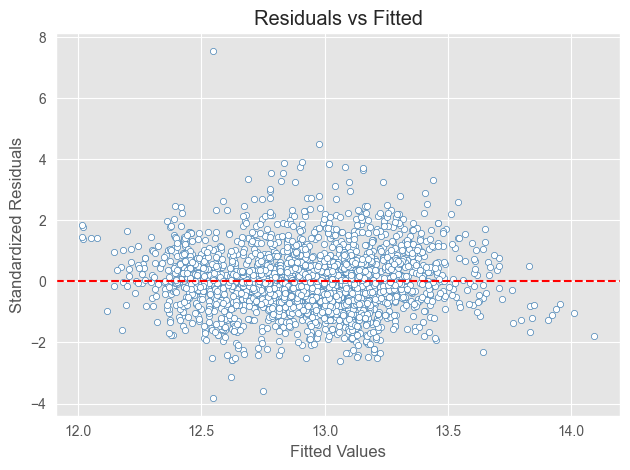

In [33]:
fig, axes = plt.subplots()
axes.scatter(model_one.fittedvalues, std_resid, edgecolors='steelblue', facecolors='white', s=20)
axes.axhline(0, color='red', linestyle='--')
axes.set_xlabel('Fitted Values')
axes.set_ylabel('Standardized Residuals')
axes.set_title('Residuals vs Fitted')

plt.tight_layout()
plt.show()

In [34]:
outlier_idx = np.where(std_resid > 3)[0]
print(df.iloc[outlier_idx])

     flat_type  floor_area_sqm  flat_model  lease_commence_date  resale_price  remaining_lease_years  average_storey      region
63      4 ROOM            94.0     Model A                 2012      682888.0              91.166667            11.0  North-East
78      4 ROOM            90.0     Model A                 2003      640000.0              82.166667             8.0  North-East
377     3 ROOM            75.0    Standard                 1973      723000.0              51.583333             2.0     Central
393     4 ROOM            90.0     Model A                 2002      820000.0              81.500000             5.0     Central
568     3 ROOM            70.0    Improved                 1977      496000.0              55.666667             8.0     Central
737     4 ROOM            90.0     Model A                 2002      610888.0              81.500000             8.0        West
758     5 ROOM           117.0    Improved                 2013      845000.0              92.166

In [35]:
n, p = X_processed.shape
cooks_d = (std_resid**2 / p) * (leverage / (1 - leverage))
influential_idx = np.where(cooks_d > 1)[0]

print(influential_idx)

[]


In [36]:
# Drop constant column for VIF calculation
X_vif = X_processed_df.drop(columns='const')

vif = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif = vif.sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif)

                              Feature          VIF
0                 lease_commence_date  2841.313322
1                    flat_type_4 ROOM   554.947690
2                  flat_model_Model A   423.216596
3                    flat_type_5 ROOM   375.738707
4                      floor_area_sqm   353.001603
5                    flat_type_3 ROOM   321.749070
6                 flat_model_Improved   314.860396
7           flat_model_New Generation   158.175918
8                 flat_type_EXECUTIVE   136.410852
9        flat_model_Premium Apartment   132.353089
10              remaining_lease_years   102.220643
11               flat_model_Apartment    56.173973
12              flat_model_Simplified    45.886733
13              flat_model_Maisonette    41.014230
14                    flat_model_DBSS    40.532823
15                flat_model_Standard    37.337610
16                   flat_type_2 ROOM    32.522978
17                flat_model_Model A2    11.288073
18                  region_Nort

Comments: VIF for some regressors are quite high, especially lease_commence_date, flat_type, flat_model. For eg., lease_commence_date has a VIF of 2841.313322. A multicollinearity problem definitely exists.

In [37]:
def cramers_v(col1, col2):
    contingency = pd.crosstab(col1, col2)
    chi2, p, dof, _ = chi2_contingency(contingency)
    n = contingency.sum().sum()
    v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
    return chi2, p, v


chi2, p, v = cramers_v(df['flat_type'], df['flat_model'])

print(p < 0.05)

True


Conducting chi squared test of independence between flat_type and flat_model,

H0: The two variables are independent. H1: The two variables are dependent

Under H0, we strongly reject the null hypothesis as the P-value is less than 0.05. We can conclude that the two variables are not independent.

In [38]:
chi2, p, v = cramers_v(df['lease_commence_date'], df['remaining_lease_years'])
print(p < 0.05)

True


Conducting chi squared test of independence between `lease_commence_date` and `remaining_lease_years`,

H0: The two variables are independent. H1: The two variables are dependent

Under H0, we strongly reject the null hypothesis as the P-value is less than 0.05. We can conclude that the two variables are not independent.

## **Model 2: Ridge Regression**

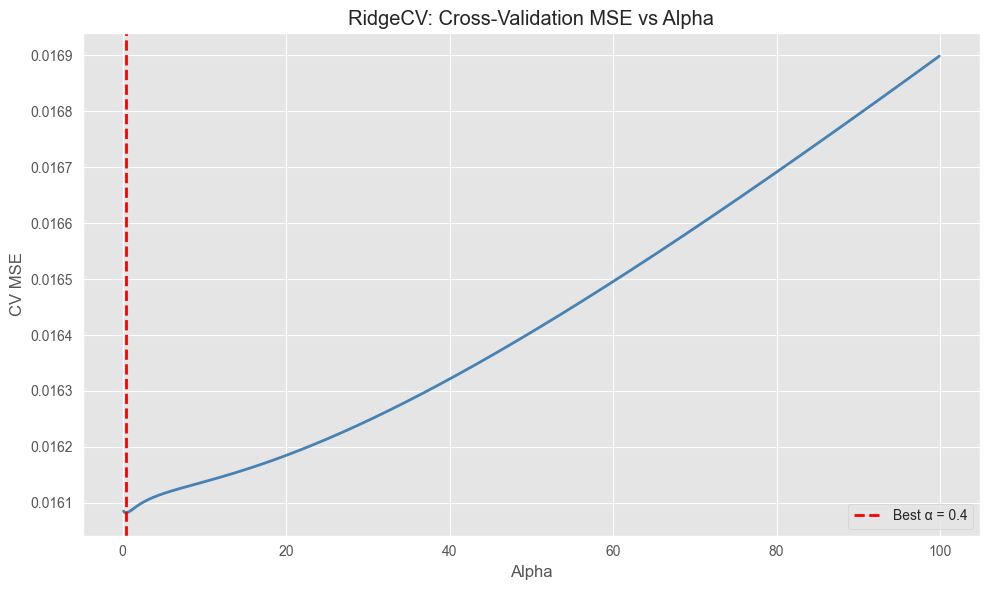

Best alpha: 0.4


In [39]:
alphas = np.arange(0.1, 100, 0.1)

ridge_cv = RidgeCV(alphas=alphas, store_cv_results=True)
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X_processed)

ridge_cv.fit(X_scaled, y)

cv_mse = cv_mse = ridge_cv.cv_results_.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(alphas, cv_mse, lw=2, color='steelblue')
ax.axvline(ridge_cv.alpha_, color='red', linestyle='--', lw=2, 
           label=f"Best α = {ridge_cv.alpha_}")
ax.set_title("RidgeCV: Cross-Validation MSE vs Alpha")
ax.set_xlabel("Alpha")
ax.set_ylabel("CV MSE")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Best alpha: {ridge_cv.alpha_}")


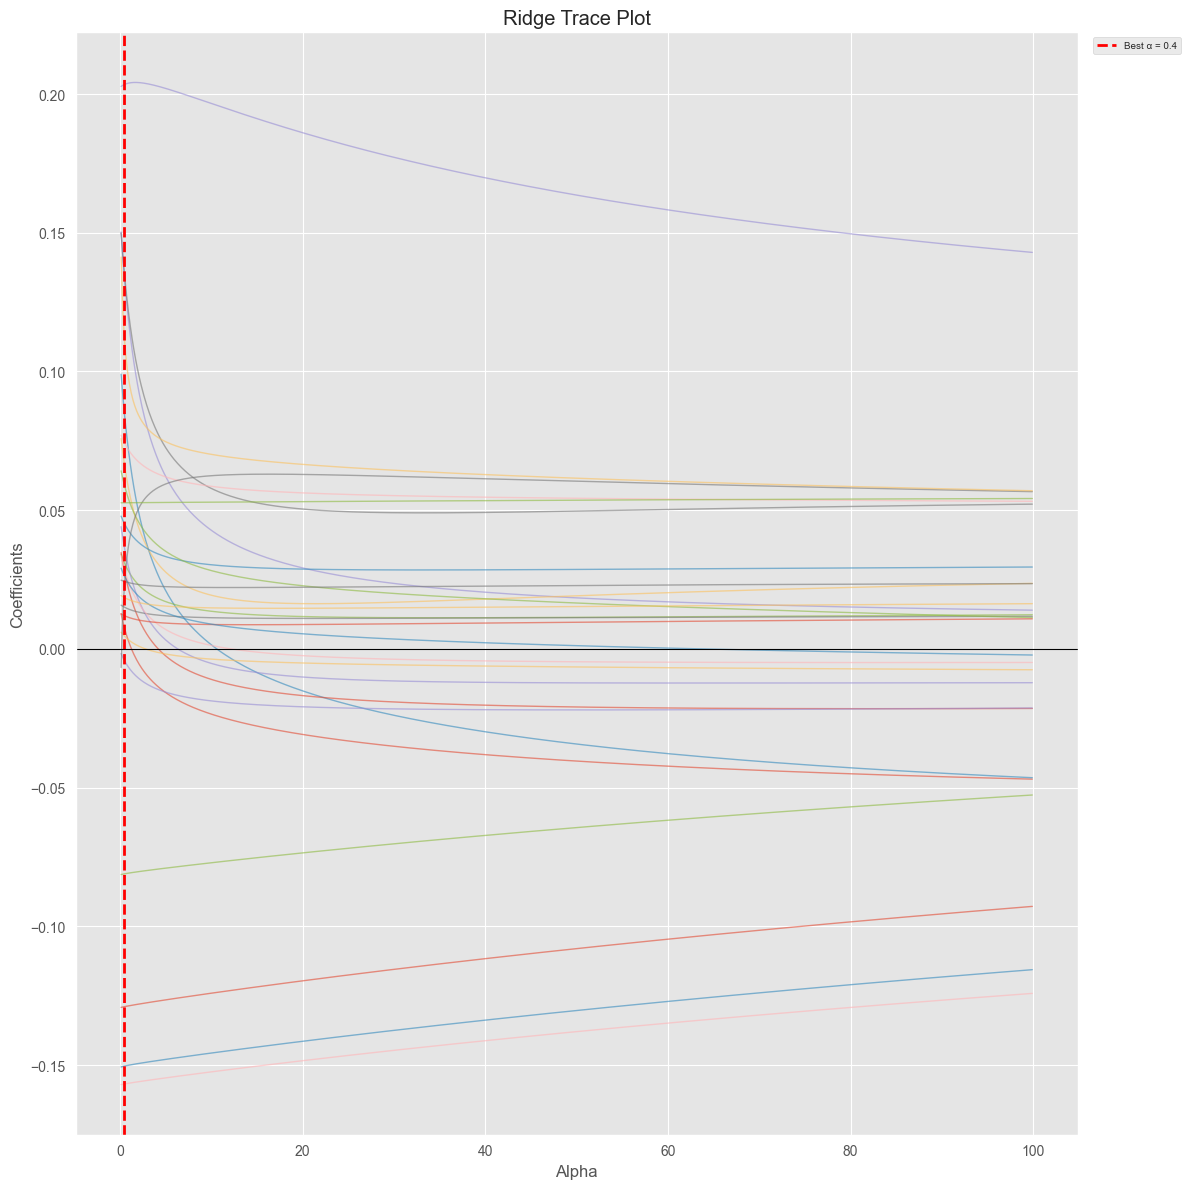

In [40]:
alphas = np.arange(0.1, 100, 0.1)

coefs = []
for alpha in alphas:
    r = Ridge(alpha=alpha)
    r.fit(X_scaled, y)
    coefs.append(r.coef_)

coefs = np.array(coefs)  

fig, ax = plt.subplots(figsize=(12, 12))

for i in range(coefs.shape[1]):
    ax.plot(alphas, coefs[:, i], lw=1, alpha=0.6)

ax.axvline(ridge_cv.alpha_, color='red', linestyle='--', lw=2, 
           label=f"Best α = {ridge_cv.alpha_}")
ax.axhline(0, color='black', linestyle='-', lw=0.8)
ax.set_title("Ridge Trace Plot")
ax.set_xlabel("Alpha")
ax.set_ylabel("Coefficients")

ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), 
           fontsize=7, frameon=True, ncol=1)

plt.tight_layout()
plt.show()

In [41]:
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_df = pd.DataFrame(X_train_scaled, columns=all_feature_names)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=all_feature_names)
X_train_df = sm.add_constant(X_train_df)
X_test_df  = sm.add_constant(X_test_df)

y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
ols_r2 = r2_score(y_test, ols.predict(X_test_scaled))

ridge_cv = RidgeCV(alphas=alphas, store_cv_results=True)
ridge_cv.fit(X_train_scaled, y_train)
ridge_r2 = r2_score(y_test, ridge_cv.predict(X_test_scaled))

ols_mse   = mean_squared_error(y_test, ols.predict(X_test_scaled))
ridge_mse = mean_squared_error(y_test, ridge_cv.predict(X_test_scaled))

print(f"OLS Test R²: {ols_r2:.4f}")
print(f"Ridge Test R²: {ridge_r2:.4f}")

print(f"OLS   Test RMSE: {np.sqrt(ols_mse):.4f}")
print(f"Ridge Test RMSE: {np.sqrt(ridge_mse):.4f}")

OLS Test R²: 0.8572
Ridge Test R²: 0.8573
OLS   Test RMSE: 0.1253
Ridge Test RMSE: 0.1252


Comments: R^2 value and mean squared error dont differ by much between model 1 and the ridge regression model.

## **Model 3: Subset Regression Model with lease_commence_date and flat_type dropped**

From the analysis previously, we found out that there exists some multicollinearity in the base model, particularly between flat_type and flat_model and between lease_commence_date and remaining_lease_years.

Betweeen lease_commence_date and remaining_lease_years, we have also seen that from the plot previously, they are positively associated. So we will choose to drop one of these variables which is lease_commence_date.

For the remaining feature variables, we will run forward selection to select feature variables

In [42]:
def forward_selection(df, categorical_features, numerical_features, y):
    all_features = categorical_features + numerical_features
    selected = []
    remaining = all_features.copy()
    best_aic = np.inf
    
    print(f"{'Step':<6} {'Added Feature':<35} {'AIC':<15} {'Adj R²':<10}")
    print("-" * 70)
    
    while remaining:
        aic_candidates = []
        
        for candidate in remaining:
            current_features = selected + [candidate]
            
            # Split into cat and num
            cat = [f for f in current_features if f in categorical_features]
            num = [f for f in current_features if f in numerical_features]
            
            # Preprocess
            transformers = []
            if cat:
                transformers.append(('cat', OneHotEncoder(drop='first', sparse_output=False), cat))
            
            pre = ColumnTransformer(transformers=transformers, remainder='passthrough' if num else 'drop')
            X_cand = df[current_features]
            X_proc = pre.fit_transform(X_cand)
            
            # Feature names
            cat_names = list(pre.named_transformers_['cat'].get_feature_names_out(cat)) if cat else []
            feat_names = cat_names + num
            
            X_df = pd.DataFrame(X_proc, columns=feat_names)
            X_df = sm.add_constant(X_df)
            y_reset = y.reset_index(drop=True)
            
            m = sm.OLS(y_reset, X_df).fit()
            aic_candidates.append((candidate, m.aic, m.rsquared_adj))
        
        # Pick candidate with lowest AIC
        aic_candidates.sort(key=lambda x: x[1])
        best_candidate, candidate_aic, candidate_adjr2 = aic_candidates[0]
        
        # Stop if AIC doesn't improve
        if candidate_aic >= best_aic:
            print(f"\nStopped — AIC did not improve.")
            break
        
        selected.append(best_candidate)
        remaining.remove(best_candidate)
        best_aic = candidate_aic
        
        print(f"{len(selected):<6} {best_candidate:<35} {candidate_aic:<15.4f} {candidate_adjr2:<10.4f}")
    
    print(f"\nSelected features: {selected}")
    return selected


new_categorical_features = ["flat_model", "region"]
new_numerical_features   = ["floor_area_sqm", "remaining_lease_years", "average_storey"]

selected_features = forward_selection(df, new_categorical_features, new_numerical_features, y)

Step   Added Feature                       AIC             Adj R²    
----------------------------------------------------------------------
1      floor_area_sqm                      -65.3098        0.4923    
2      flat_model                          -875.7308       0.6371    
3      region                              -1583.4216      0.7285    
4      remaining_lease_years               -2758.4484      0.8319    
5      average_storey                      -3098.1051      0.8537    

Selected features: ['floor_area_sqm', 'flat_model', 'region', 'remaining_lease_years', 'average_storey']


In [43]:
new_preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', sparse_output=False), new_categorical_features)
], remainder='passthrough')

X_new = df[new_categorical_features + new_numerical_features]
X_processed_new = new_preprocessor.fit_transform(X_new)

new_cat_feature_names = new_preprocessor.named_transformers_['cat'].get_feature_names_out(new_categorical_features)
new_all_feature_names = list(new_cat_feature_names) + new_numerical_features  

X_processed_new_df = sm.add_constant(pd.DataFrame(X_processed_new, columns=new_all_feature_names))

model_three = sm.OLS(y, X_processed_new_df).fit()
print(model_three.summary())

                            OLS Regression Results                            
Dep. Variable:           resale_price   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     682.4
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:45:01   Log-Likelihood:                 1571.1
No. Observations:                2454   AIC:                            -3098.
Df Residuals:                    2432   BIC:                            -2970.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [44]:
print(f"R^2 Adjusted for model 1: {model_one.rsquared_adj}")
print(f"R^2 Adjusted for model 3: {model_three.rsquared_adj}")

R^2 Adjusted for model 1: 0.8585593090297841
R^2 Adjusted for model 3: 0.8536527775676814


In [45]:
print(f"AIC for model 1: {model_one.aic:.4f}")
print(f"BIC for model 1: {model_one.bic:.4f}")
print(f"AIC for model 3: {model_three.aic:.4f}")
print(f"BIC for model 3: {model_three.bic:.4f}")

AIC for model 1: -3175.8521
BIC for model 1: -3013.2988
AIC for model 3: -3098.1051
BIC for model 3: -2970.3847


In [46]:
influence = model_three.get_influence()
leverage = influence.hat_matrix_diag
std_resid = influence.resid_studentized_internal  

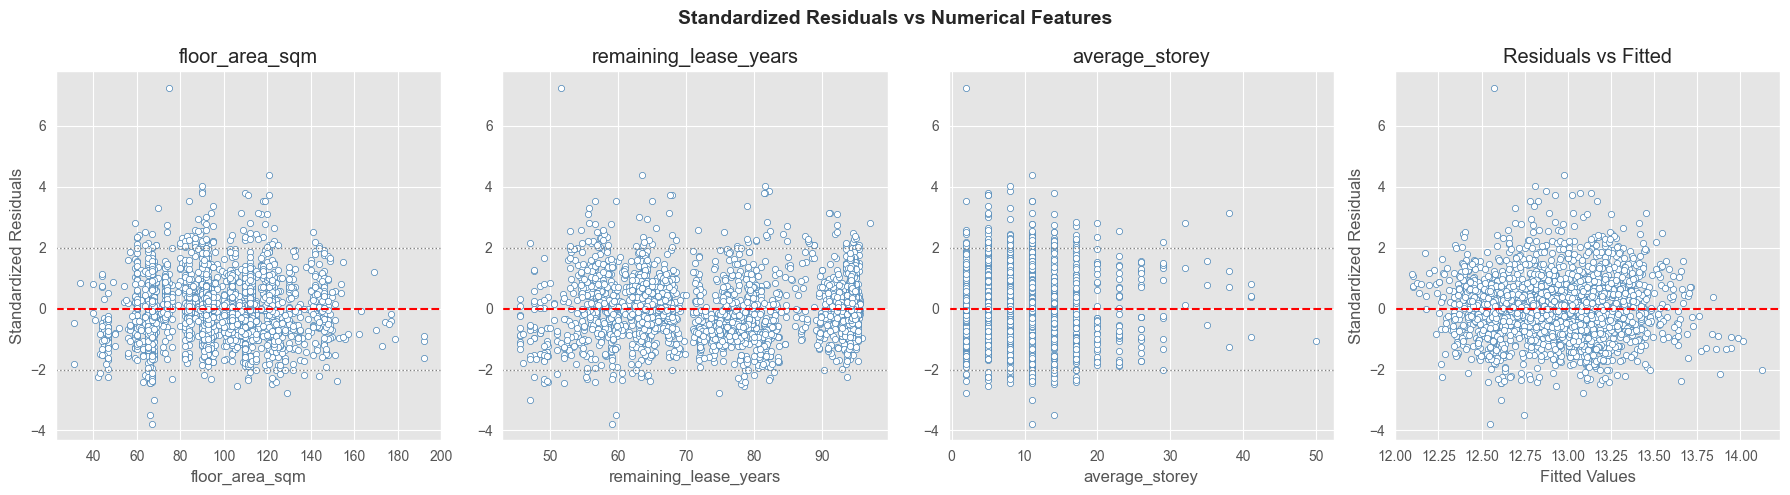

In [47]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Standardized Residuals vs Numerical Features", fontsize=14, fontweight='bold')

for i, feature in enumerate(new_numerical_features):
    ax = axes[i]
    ax.scatter(df[feature], std_resid, edgecolors='steelblue', facecolors='white', s=20)

    ax.axhline(0, color='red', linestyle='--', lw=1.5)
    ax.axhline(2, color='gray', linestyle=':', lw=1)
    ax.axhline(-2, color='gray', linestyle=':', lw=1)
    ax.set_xlabel(feature)
    ax.set_ylabel("Standardized Residuals" if i == 0 else "")
    ax.set_title(feature)

axes[3].scatter(model_three.fittedvalues, std_resid, edgecolors='steelblue', facecolors='white', s=20)
axes[3].axhline(0, color='red', linestyle='--')
axes[3].set_xlabel('Fitted Values')
axes[3].set_ylabel('Standardized Residuals')
axes[3].set_title('Residuals vs Fitted')

plt.tight_layout()
plt.show()

In [48]:
outlier_idx = np.where(std_resid > 3)[0]
print(df.iloc[outlier_idx])

     flat_type  floor_area_sqm  flat_model  lease_commence_date  resale_price  remaining_lease_years  average_storey      region
63      4 ROOM            94.0     Model A                 2012      682888.0              91.166667            11.0  North-East
78      4 ROOM            90.0     Model A                 2003      640000.0              82.166667             8.0  North-East
377     3 ROOM            75.0    Standard                 1973      723000.0              51.583333             2.0     Central
393     4 ROOM            90.0     Model A                 2002      820000.0              81.500000             5.0     Central
568     3 ROOM            70.0    Improved                 1977      496000.0              55.666667             8.0     Central
737     4 ROOM            90.0     Model A                 2002      610888.0              81.500000             8.0        West
758     5 ROOM           117.0    Improved                 2013      845000.0              92.166

In [49]:
n, p = X_processed_new.shape
cooks_d = (std_resid**2 / p) * (leverage / (1 - leverage))
influential_idx = np.where(cooks_d > 1)[0]

print(influential_idx)

[]


In [50]:

X_vif = X_processed_new_df.drop(columns='const')

vif = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif = vif.sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif)

                              Feature        VIF
0               remaining_lease_years  65.252839
1                      floor_area_sqm  28.613926
2                  flat_model_Model A  27.439593
3                 flat_model_Improved  18.499807
4        flat_model_Premium Apartment  10.348193
5           flat_model_New Generation   6.760687
6                flat_model_Apartment   4.945201
7                     flat_model_DBSS   4.005787
8                   region_North-East   3.960599
9                      average_storey   3.885279
10              flat_model_Maisonette   3.691107
11                        region_West   3.383386
12              flat_model_Simplified   2.888557
13                       region_North   2.724377
14                        region_East   2.583583
15                flat_model_Standard   2.120157
16                flat_model_Model A2   1.579627
17                 flat_model_Type S1   1.227001
18  flat_model_Premium Apartment Loft   1.188318
19      flat_model_M

In [51]:
model_three.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           resale_price   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     682.4
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:45:02   Log-Likelihood:                 1571.1
No. Observations:                2454   AIC:                            -3098.
Df Residuals:                    2432   BIC:                            -2970.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                11.1998      0.094    119.596      0.000      11.016      11.383
flat_model_Apartment                  0.0942      0.092      1.028      0.304      -0.086       0.274
flat_model_DBSS                       0.5028      0.093      5.429      0.000       0.321       0.684
flat_model_Improved                   0.1329      0.091      1.460      0.144      -0.046       0.312
flat_model_Maisonette                 0.2022      0.092      2.199      0.028       0.022       0.383
flat_model_Model A                    0.1372      0.091      1.502      0.133      -0.042       0.316
flat_model_Model A-Maisonette         0.3489      0.107      3.253      0.001       0.139       0.559
flat_model_Model A2                   0.1419      0.096      1.484      0.138      -0.046       0.329
flat_model_New Generation             0.2553      0.091      2.791      0.005       0.076       0.435
flat_model_Premium Apartment          0.1548      0.092      1.691      0.091      -0.025       0.334
flat_model_Premium Apartment Loft     0.3525      0.112      3.153      0.002       0.133       0.572
flat_model_Simplified                 0.2462      0.092      2.669      0.008       0.065       0.427
flat_model_Standard                   0.0546      0.092      0.591      0.554      -0.127       0.236
flat_model_Terrace                    0.8369      0.128      6.521      0.000       0.585       1.089
flat_model_Type S1                    0.4736      0.108      4.383      0.000       0.262       0.685
region_East                          -0.2243      0.010    -22.236      0.000      -0.244      -0.205
region_North                         -0.4339      0.011    -40.894      0.000      -0.455      -0.413
region_North-East                    -0.2956      0.010    -29.755      0.000      -0.315      -0.276
region_West                          -0.3549      0.010    -36.964      0.000      -0.374      -0.336
floor_area_sqm                        0.0105      0.000     74.016      0.000       0.010       0.011
remaining_lease_years                 0.0098      0.000     35.983      0.000       0.009       0.010
average_storey                        0.0095      0.000     19.060      0.000       0.009       0.010
==============================================================================
Omnibus:                      231.589   Durbin-Watson:                   0.926
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              508.857
Skew:                           0.583   Prob(JB):                    3.18e-111
Kurtosis:                       4.902   Cond. No.                     1.71e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matr

## **Model 4: WLS Model**

In [52]:
def irls(y, X_df, tol=1e-6, max_iter=100):
    y = np.asarray(y)
    n = len(y)
    weights = np.ones(n)

    print(f"{'Iter':<6} {'Max Weight Change':<20} {'WRSS':<15}")
    print("-" * 45)

    for i in range(max_iter):
        wls = sm.WLS(y, X_df, weights=weights).fit()

        resid_sq = wls.resid ** 2
        var_model = sm.OLS(resid_sq, X_df).fit()
        fitted_var = np.clip(var_model.fittedvalues, 1e-6, None)

        new_weights = 1 / fitted_var

        # Cap weights to prevent explosive upweighting of near-zero variance obs
        new_weights = np.clip(new_weights, 0, np.percentile(new_weights, 99))

        weight_change = np.max(np.abs(new_weights - weights))
        wrss = np.sum(new_weights * wls.resid ** 2)

        print(f"{i+1:<6} {weight_change:<20.6f} {wrss:<15.4f}")

        if weight_change < tol:
            print(f"\nConverged at iteration {i+1}")
            break

        weights = new_weights
    else:
        print(f"\nDid not converge after {max_iter} iterations")

    return wls, weights

final_wls, final_weights = irls(y, X_processed_new_df)
print(final_wls.summary())

Iter   Max Weight Change    WRSS           
---------------------------------------------
1      999999.000000        257989.8675    
2      999939.283033        285921.8175    
3      999940.236864        544994.0420    
4      999979.059077        6677984.6333   
5      999983.955660        2847128.9577   
6      999988.607206        5690496.6428   
7      999989.078378        3913272.8438   
8      999986.501080        4205365.7586   
9      999987.661345        3853834.1058   
10     999987.661345        4291296.6741   
11     999985.321202        3794679.8597   
12     999985.876195        4388509.5510   
13     999989.111948        3928363.4270   
14     999989.111948        4119401.2902   
15     999985.243909        3992032.4425   
16     999985.243909        4124749.1400   
17     999983.028864        3972679.4589   
18     999985.834006        4482956.6371   
19     999989.007601        3983080.3379   
20     999989.007601        4117647.7466   
21     999985.760885        39

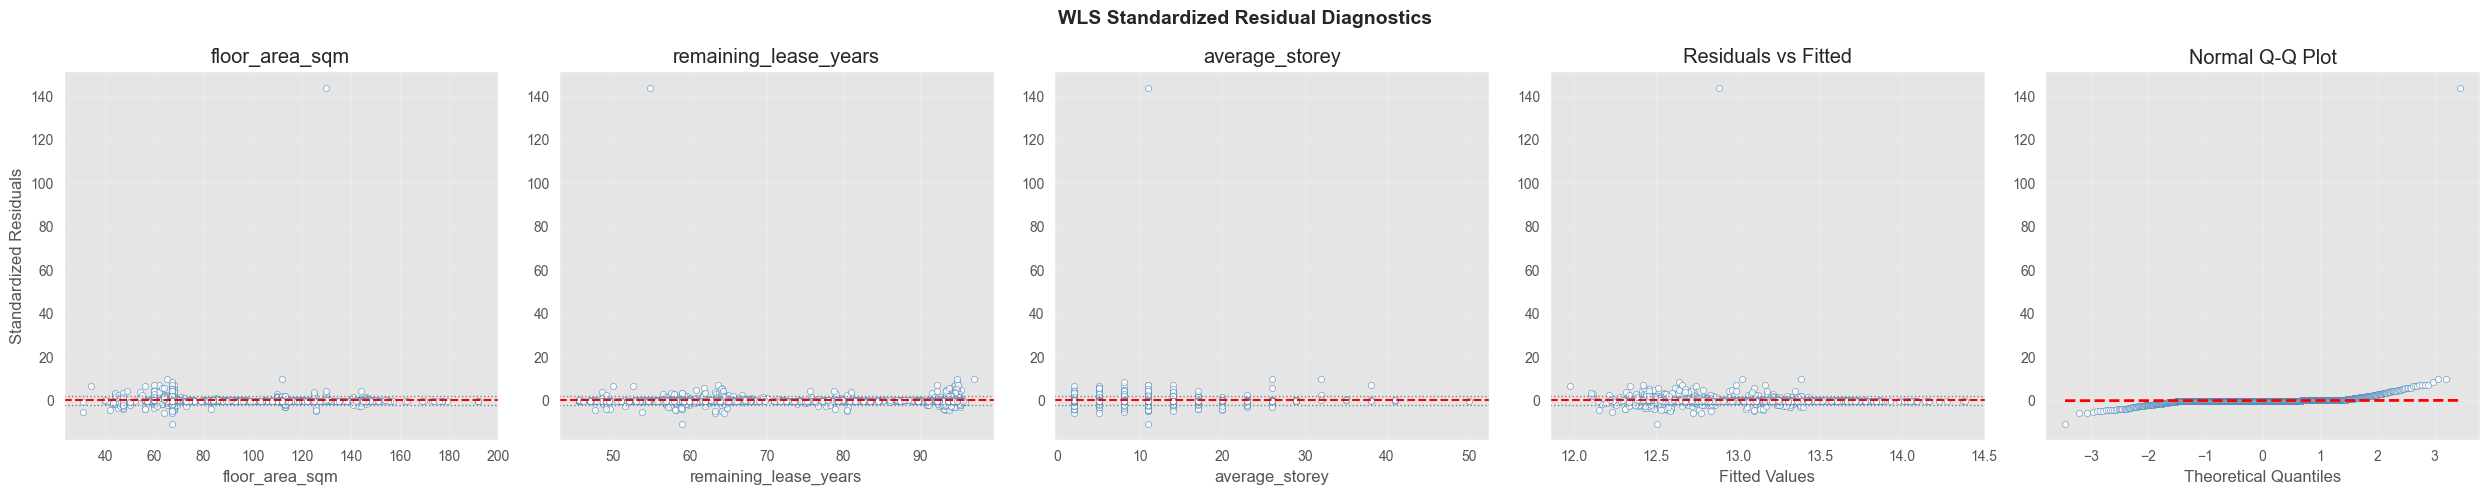

In [53]:

X = X_processed_new_df.to_numpy()
w = np.asarray(final_weights)
n, p = X.shape

W = np.diag(w)
XtWX_inv = np.linalg.inv(X.T @ W @ X)
H = X @ XtWX_inv @ X.T @ W
h = np.diag(H)

raw_resid = np.asarray(final_wls.resid)
s = np.sqrt(np.sum(w * raw_resid**2) / (n - p))
std_resid = (np.sqrt(w) * raw_resid) / (s * np.sqrt(1 - h))

# --- Plot ---
n_num = len(new_numerical_features)
fig, axes = plt.subplots(1, n_num + 2, figsize=(5 * (n_num + 2), 5))
fig.suptitle("WLS Standardized Residual Diagnostics", fontsize=14, fontweight='bold')

for i, feature in enumerate(new_numerical_features):
    ax = axes[i]
    ax.scatter(df[feature], std_resid,
               edgecolors='steelblue', facecolors='white', s=20, alpha=0.7)
    ax.axhline(0,  color='red',  linestyle='--', lw=1.5)
    ax.axhline(2,  color='gray', linestyle=':',  lw=1)
    ax.axhline(-2, color='gray', linestyle=':',  lw=1)
    ax.set_xlabel(feature)
    ax.set_ylabel("Standardized Residuals" if i == 0 else "")
    ax.set_title(feature)
    ax.grid(True, alpha=0.2)

# Residuals vs Fitted
axes[n_num].scatter(final_wls.fittedvalues, std_resid,
                    edgecolors='steelblue', facecolors='white', s=20, alpha=0.7)
axes[n_num].axhline(0,  color='red',  linestyle='--', lw=1.5)
axes[n_num].axhline(2,  color='gray', linestyle=':',  lw=1)
axes[n_num].axhline(-2, color='gray', linestyle=':',  lw=1)
axes[n_num].set_xlabel('Fitted Values')
axes[n_num].set_title('Residuals vs Fitted')
axes[n_num].grid(True, alpha=0.2)

# Q-Q plot
(osm, osr), _ = stats.probplot(std_resid, dist='norm')
axes[n_num + 1].scatter(osm, osr, edgecolors='steelblue', facecolors='white', s=20, alpha=0.7)
q25, q75 = np.percentile(std_resid, [25, 75])
nq25, nq75 = stats.norm.ppf([0.25, 0.75])
slope = (q75 - q25) / (nq75 - nq25)
intercept = q25 - slope * nq25
x_line = np.linspace(min(osm), max(osm), 100)
axes[n_num + 1].plot(x_line, slope * x_line + intercept, 'r--', lw=2)
axes[n_num + 1].set_xlabel('Theoretical Quantiles')
axes[n_num + 1].set_title('Normal Q-Q Plot')
axes[n_num + 1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()